<a href="https://colab.research.google.com/github/MartinTiong/CPE-311/blob/main/Hands_on_Activity_9_2_Customized_Visualizations_using_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction to Seaborn

About the Data

In this notebook, we will be working with 2 datasets:


Facebook's stock price throughout 2018 (obtained using the stock_analysis package)
Earthquake data from September 18, 2018 - October 13, 2018 (obtained from the US Geological Survey (USGS) using the USGS API)

Setup

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
fb = pd.read_csv(
'/content/fb_stock_prices_2018 (1).csv', index_col='date', parse_dates=True
)
quakes = pd.read_csv('/content/earthquakes-1 (1).csv')

Categorical data

A 7.5 magnitude earthquake on September 28, 2018 near Palu, Indonesia caused a devastating tsunami afterwards. Let's take a look at some visualizations to understand
what magTypes are used in Indonesia, the range of magnitudes there, and how many of the earthquakes are accompanied by a tsunami

In [3]:
quakes.assign(
time=lambda x: pd.to_datetime(x.time, unit='ms')
).set_index('time').loc['2018-09-28'].query(
"parsed_place == 'Indonesia' and tsunami == 1 and mag == 7.5"
)


,mag,magType,place,tsunami,parsed_place
time,,,,,
2018-09-28 10:02:43.480,7.5,mww,"78km N of Palu, Indonesia",1,Indonesia


stripplot()

The stripplot() function helps us visualize categorical data on one axis and numerical data on the other. We also now have the option of coloring our points using a
column of our data (with the hue parameter). Using a strip plot, we can see points for each earthquake that was measured with a given magType and what its magnitude
was; however, it isn't too easy to see density of the points due to overlap:

<Axes: xlabel='magType', ylabel='mag'>

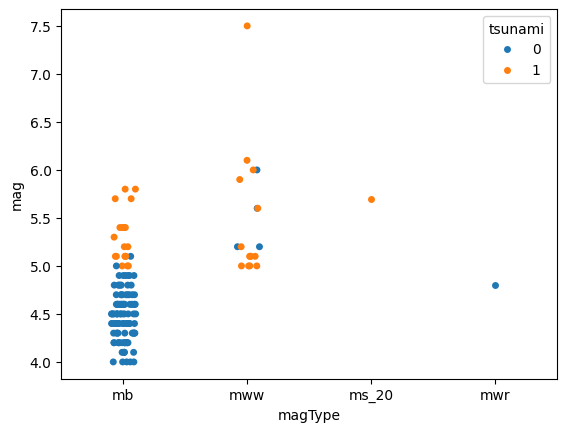

In [4]:
sns.stripplot(
x='magType',
y='mag',
hue='tsunami',
data=quakes.query('parsed_place == "Indonesia"')
)

This strip plot shows us the display of the distribution of a numerical variable across different categories, showing individual data points along a single axis, which are in this case, the magtype and the mag.

swarmplot()

The bee swarm plot helps address this issue be keeping the points from overlapping. Notice how many more points we can see for the blue section of the mb magType :Out[3]:In [4]:
sns.stripplot(
x='magType',
y='mag',
hue='tsunami',
data=quakes.query('parsed_place == "Indonesia"')
)Out[4]:


<Axes: xlabel='magType', ylabel='mag'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


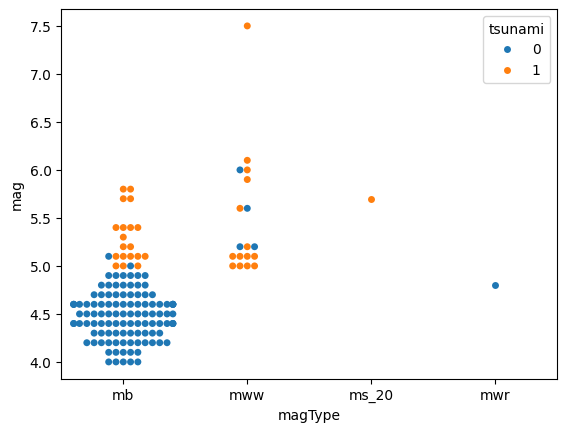

In [6]:
sns.swarmplot(
x='magType',
y='mag',
hue='tsunami',
data=quakes.query('parsed_place == "Indonesia"') )

The warning 10.2% of the points cannot be placed indicates there are too many overlapping data points. Seaborn suggests decreasing marker size or using a stripplot instead.

Correlations and Heatmaps
heatmap()

An easier way to create correlation matrix is to use seaborn :

<Axes: >

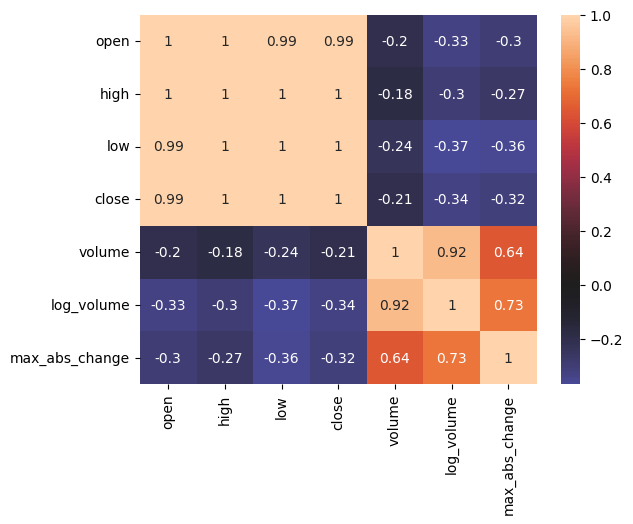

In [7]:
sns.heatmap(
fb.sort_index().assign(
log_volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).corr(),
annot=True, center=0
)

 This heatmap visualizes the correlation matrix of Facebook's stock data, specifically showing relationships between log_volume and max_abs_change along with other stock metrics. The annot=True parameter adds the correlation values to the heatmap, and center=0 sets the midpoint of the color scale at zero.

pairplot()

The pair plot is seaborn's answer to the scatter matrix we saw in the pandas subplotting notebook:

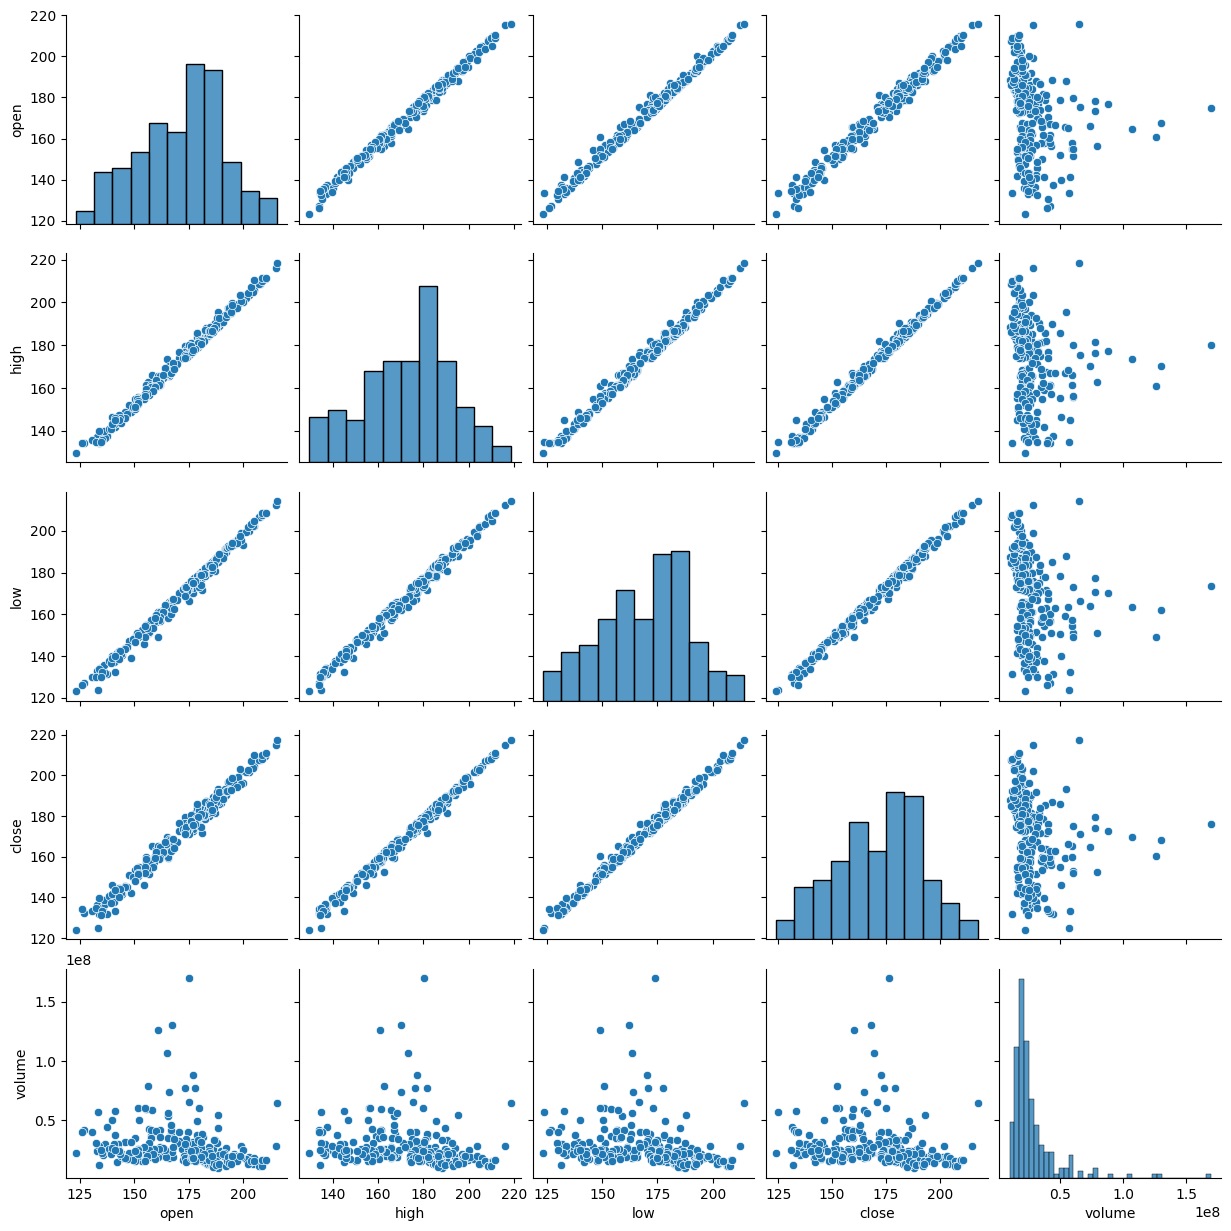

In [8]:
sns.pairplot(fb)

ust as with pandas we can specify what to show along the diagonal; however, seaborn also allows us to color the data based on another column (or other data with the
same shape):

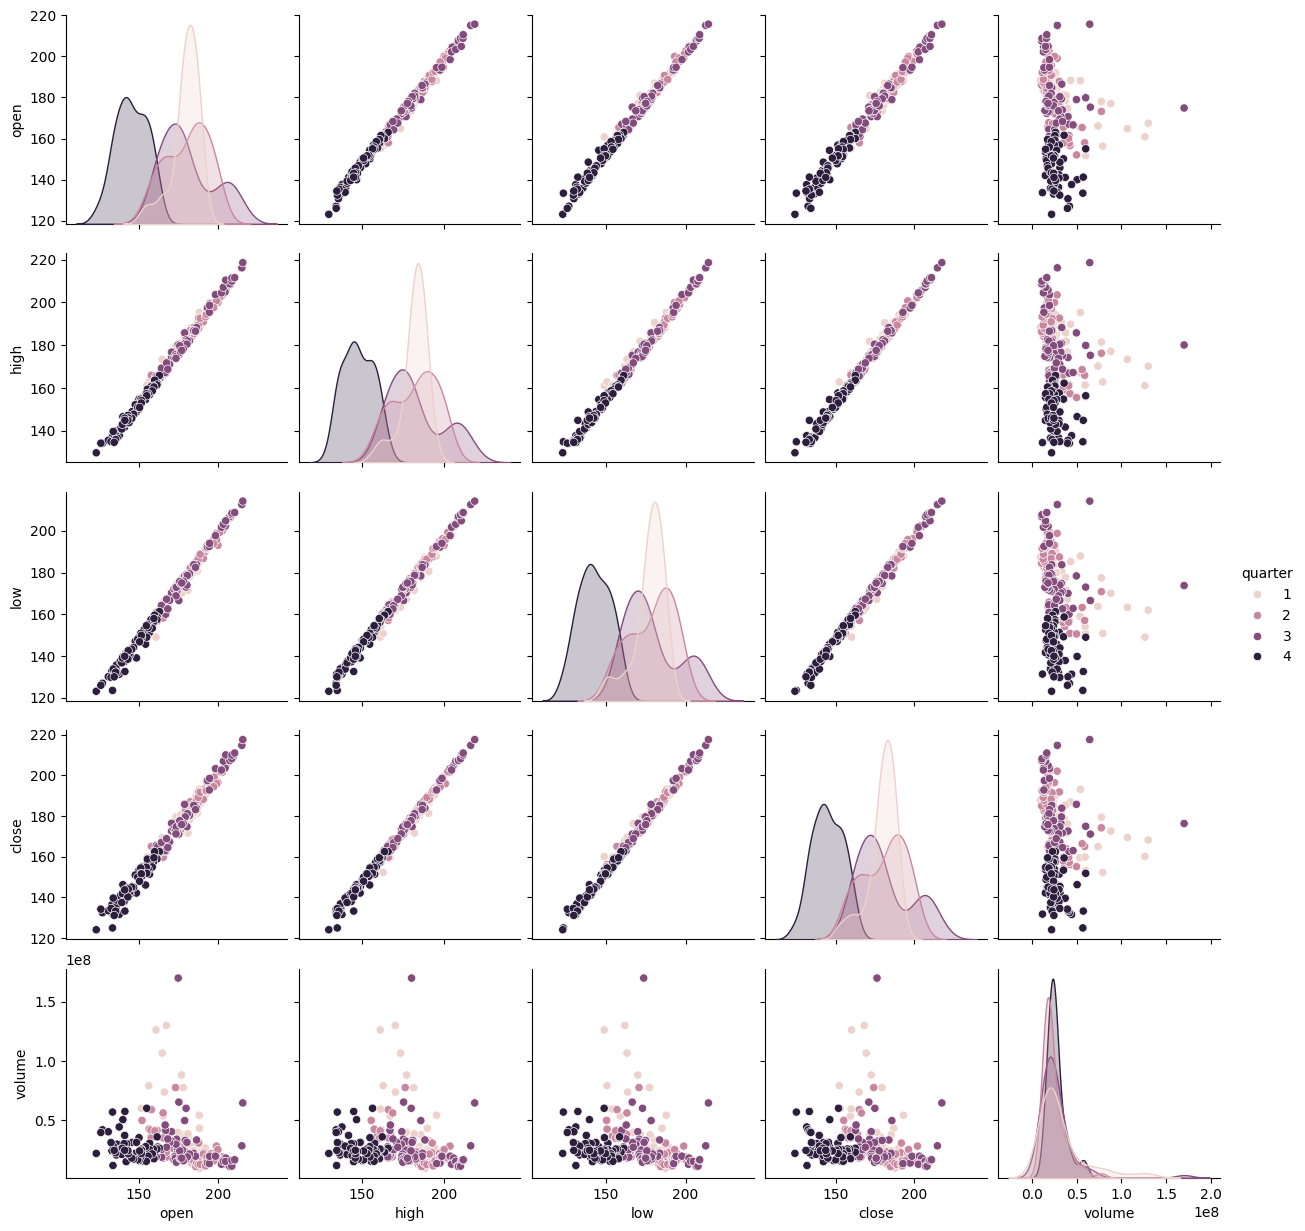

In [9]:
sns.pairplot(
fb.assign(quarter=lambda x: x.index.quarter),
diag_kind='kde',
hue='quarter')

This visualization creates a grid of pairwise relationships between variables of the dataset. It shows a quick overview of potential relationships and distributions among multiple variables.

Jointplot()

The joint plot allows us to visualize the relationship between two variables, like a scatter plot. However, we get the added benefit of being able to visualize their distributions at
the same time (as a histogram or KDE). The default options give us a scatter plot in the center and histograms on the sides:

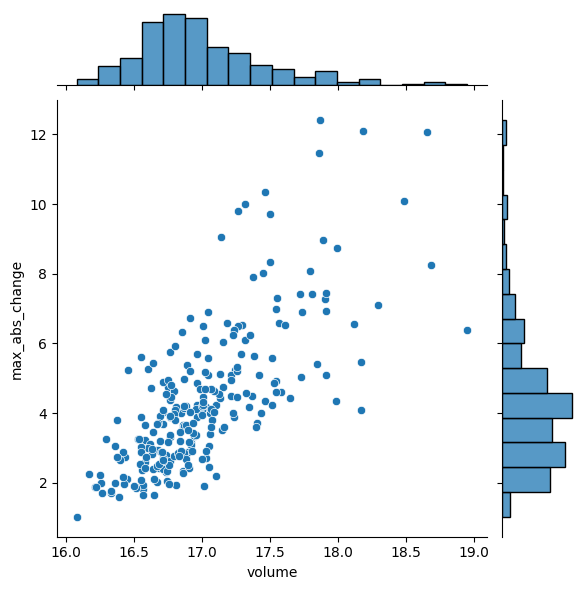

In [12]:
sns.jointplot(
x='volume',
y='max_abs_change',
data=fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low))

 It visualizes the relationship between two variables (like a scatter plot) and simultaneously shows their individual distributions (histograms or KDEs) on the margins.

By changing the kind argument, we can change how the center of the plot is displayed. For example, we can pass kind='hex' for hexbins:

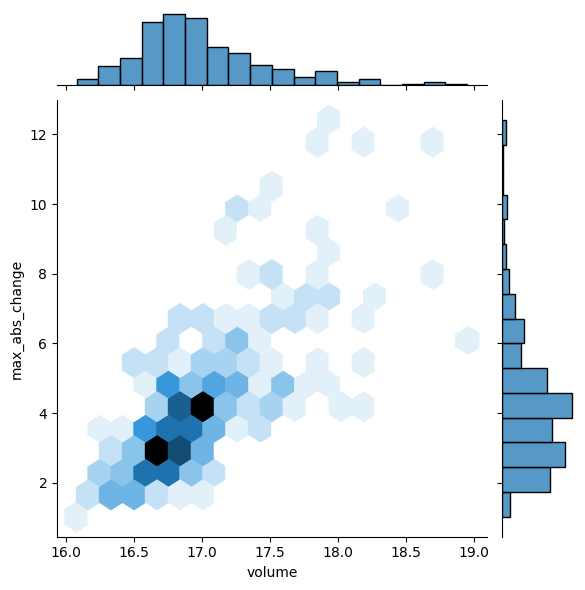

In [13]:
sns.jointplot(
x='volume',
y='max_abs_change',
kind='hex',
data=fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low))

This is similar to the first one but with hexes

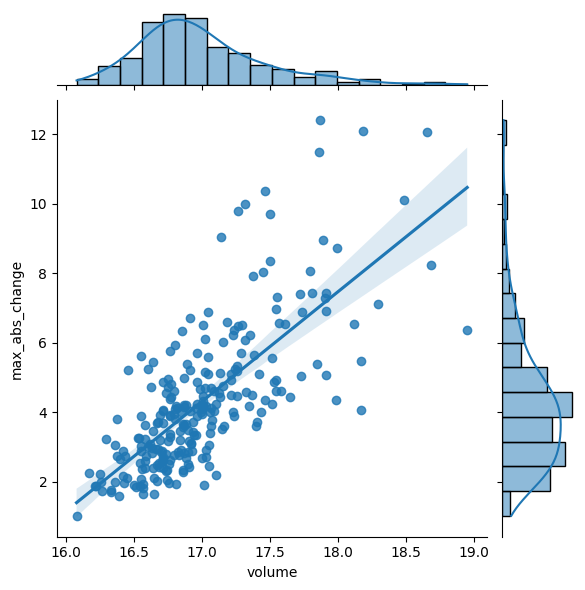

In [15]:
sns.jointplot(
x='volume',
y='max_abs_change',
kind='reg',
data=fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low))

 this was using reg displays a scatter plot with a linear regression line, plus marginal histograms.

If we pass kind='resid' , we get the residuals from the aforementioned regression:

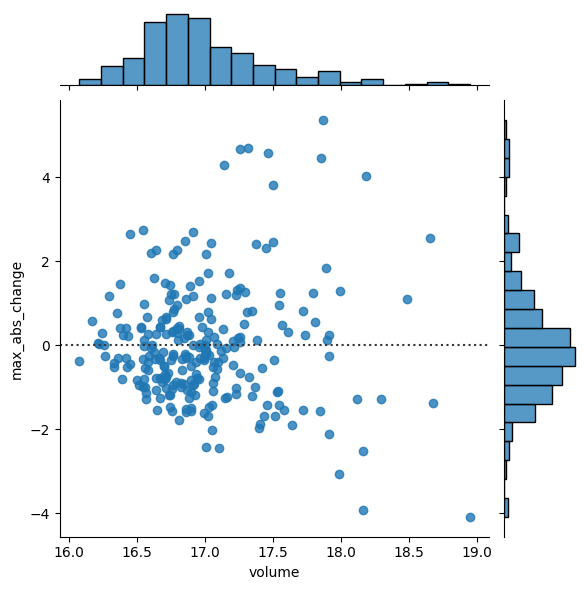

In [16]:
sns.jointplot(
x='volume',
y='max_abs_change',
kind='resid',
data=fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low))

the resid shows a scatter plot of residuals from a linear regression, with marginal distributions of these residuals

Finally, if we pass kind='kde' , we get a contour plot of the joint density estimate with KDEs along the sides:

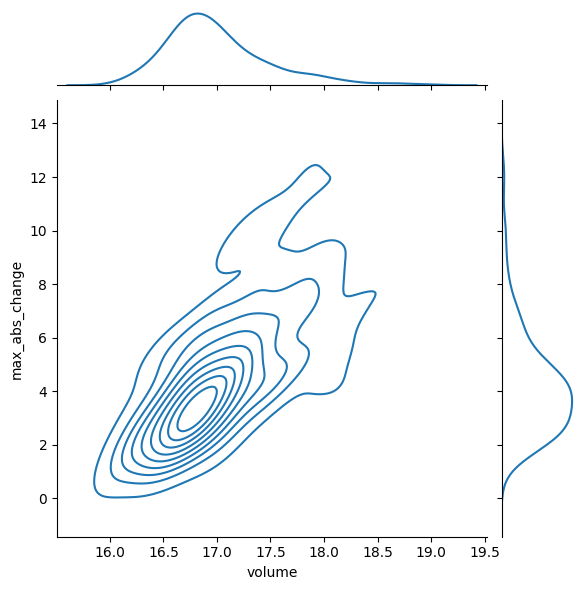

In [17]:
sns.jointplot(
x='volume',
y='max_abs_change',
kind='kde',
data=fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low))

this one uses joint density

Regression plots


We are going to use seaborn to visualize a linear regression between the log of the volume traded in Facebook stock and the maximum absolute daily change (daily high
stock price - daily low stock price). To do so, we first need to isolate this data:

In [18]:
fb_reg_data = fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).iloc[:,-2:]

Since we want to visualize each column as the regressor, we need to look at permutations of their order. Permutations and combinations (among other things) are made easy
in Python with itertools , so let's import it:

In [24]:
import itertools

itertools gives us efficient iterators. Iterators are objects that we loop over, exhausting them. This is an iterator from itertools ; notice how the second loop doesn't
do anything:

In [25]:
iterator = itertools.repeat("I'm an iterator", 1)

for i in iterator:
 print(f'-->{i}')
print('This printed once because the iterator has been exhausted')
for i in iterator:
 print(f'-->{i}')

-->I'm an iterator
This printed once because the iterator has been exhausted


iterables are objects that can be iterated over. When entering a loop, an iterator is made from the iterable to handle the iteration. Iterators are iterables, but not all iterables
are iterators. A list is an iterable. If we turn that iterator into an iterable (a list in this case), the second loop runs:

In [26]:
iterable = list(itertools.repeat("I'm an iterable", 1))
for i in iterable:
 print(f'-->{i}')
print('This prints again because it\'s an iterable:')
for i in iterable:
 print(f'-->{i}')

-->I'm an iterable
This prints again because it's an iterable:
-->I'm an iterable


he reg_resid_plots() function from the reg_resid_plot.py module in this folder uses regplot() and residplot() from seaborn along with itertools to
plot the regression and residuals side-by-side

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def reg_resid_plots(data, x, y):
    sns.residplot(x=data[x], y=data[y], lowess=True)
    plt.xlabel(x)
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()

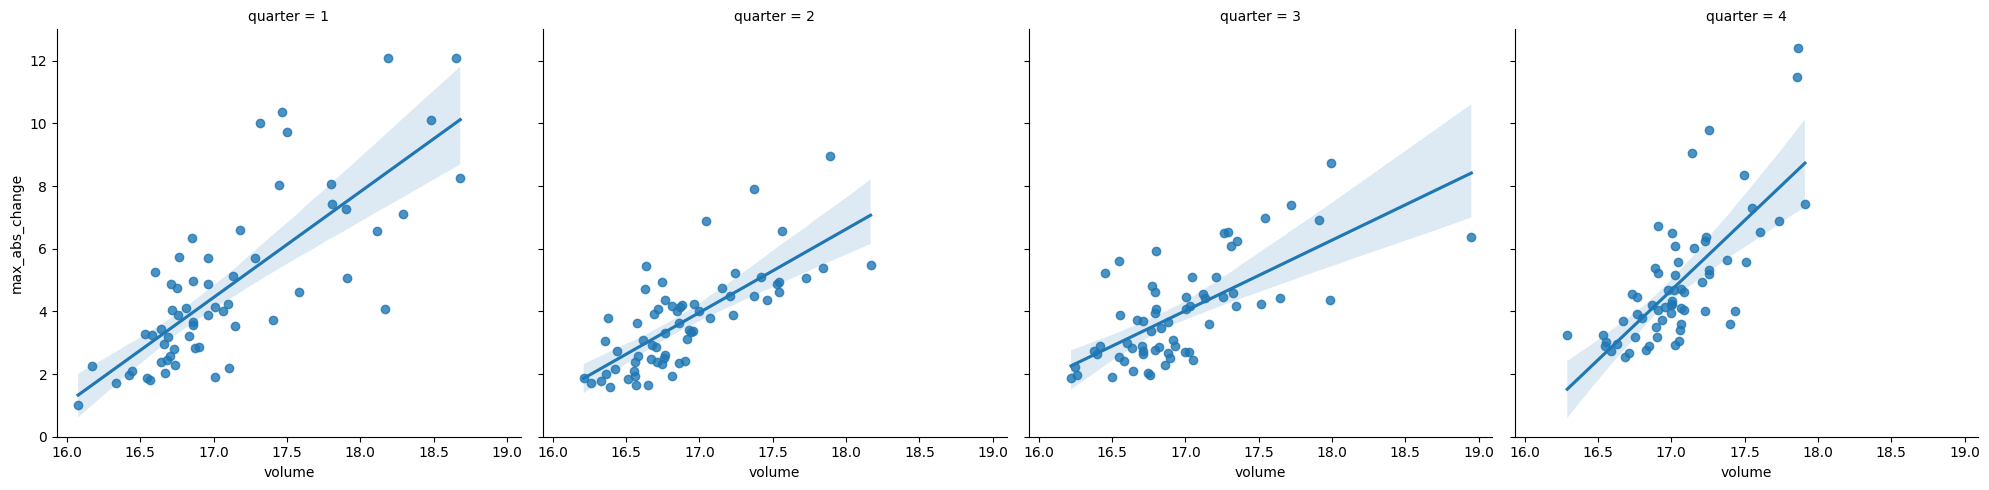

In [33]:
sns.lmplot(
x='volume',
y='max_abs_change',
data=fb.assign(
volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low,
quarter=lambda x: x.index.quarter
),
col='quarter')

 it's visualizing the relationship between log(volume) and max_abs_change for Facebook's stock prices, with separate plots for each quarter of the year, as indicated by col='quarter'.

Distributions

Seaborn provides some new plot types for visualizing distributions in additional to its own versions of the plot types we discussed in chapter 5 (in this notebook).

boxenplot()
The boxenplot is a box plot that shows additional quantiles

Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

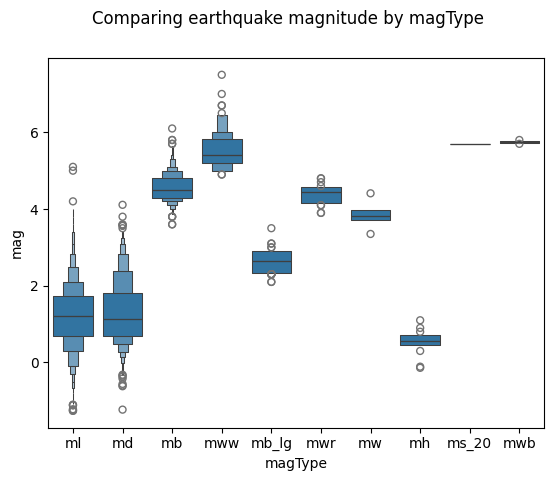

In [34]:
sns.boxenplot(
x='magType', y='mag', data=quakes[['magType', 'mag']]
)
plt.suptitle('Comparing earthquake magnitude by magType')

This boxenplot comparing earthquake magnitudes (mag) across different magnitude types (magType).

violinplot()
Box plots lose some information about the distribution, so we can use violin plots which combine box plots and KDEs:

/tmp/ipykernel_745/603559778.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


Text(0.5, 0.98, 'Comparing earthquake magnitude by magType')

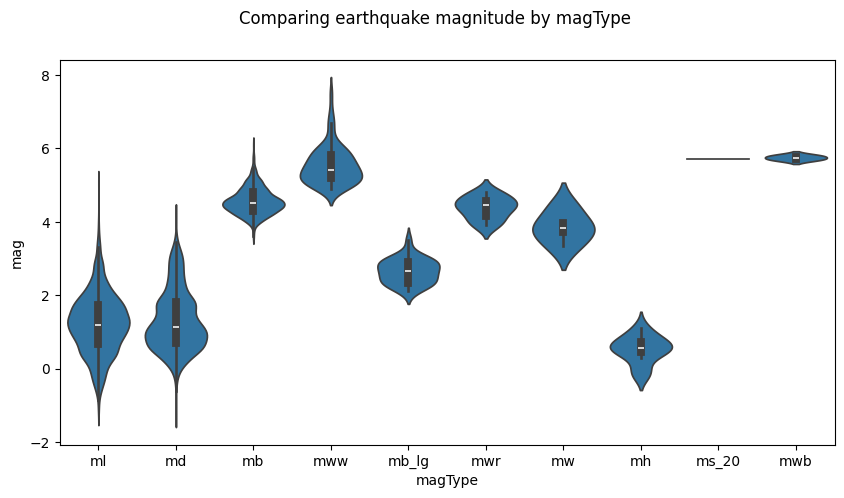

In [35]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.violinplot(
x='magType', y='mag', data=quakes[['magType', 'mag']],
ax=axes, scale='width' # all violins have same width
)
plt.suptitle('Comparing earthquake magnitude by magType')

the violin plot compares the distribution of earthquake magnitudes (mag) for different magnitude types (magType), with the scale='width' argument making all violins have the same width to facilitate comparison. It helps visualize the density and spread of magnitudes for each magType.

Faceting

We can create subplots across subsets of our data by faceting. First, we create a FacetGrid specifying how to layout the plots (which categorical column goes along the
rows and which one along the columns). Then, we call the map() method of the FacetGrid and pass in the plotting function we want to use (along with any additional
arguments).
Let's make histograms showing the distribution of earthquake magnitude in California, Alaska, and Hawaii faceted by magType and parse_placed

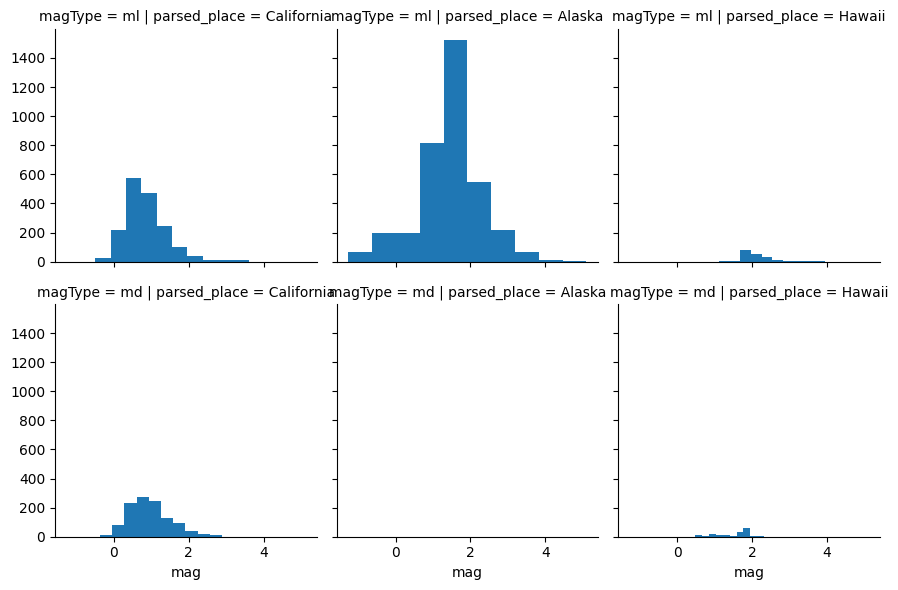

In [37]:
g = sns.FacetGrid(
quakes[
(quakes.parsed_place.isin([
'California', 'Alaska', 'Hawaii'
]))\
& (quakes.magType.isin(['ml', 'md']))
],
row='magType',
col='parsed_place'
)
g = g.map(plt.hist, 'mag')


These histograms are organized into rows by magType (e.g., 'ml', 'md') and columns by parsed_place ('California', 'Alaska', 'Hawaii'), allowing for easy comparison of magnitude distributions across these dimensions.

9.5 Formatting Plots

In this notebook, we will be working with Facebook's stock price throughout 2018 (obtained using the stock_analysis package).

Setup

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
fb = pd.read_csv(
'/content/fb_stock_prices_2018 (1).csv', index_col='date', parse_dates=True)

Titles and Axis Labels

plt.suptitle() adds a title to plots and subplots

plt.title() adds a title to a single plot. Note if you use subplots, it will only put the title on the last subplot, so you will need to use plt.suptitle()


plt.xlabel() labels the x-axis


plt.ylabel() labels the y-axis

Text(0, 0.5, 'price ($)')

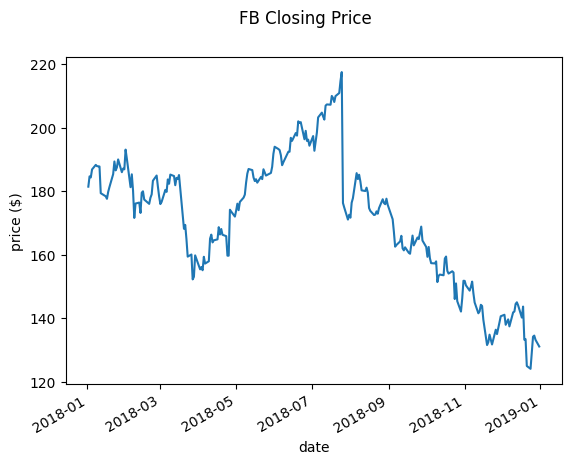

In [40]:
fb.close.plot()
plt.suptitle('FB Closing Price')
plt.xlabel('date')
plt.ylabel('price ($)')

This code plots Facebook's closing price over time. It sets 'FB Closing Price' as the main title, 'date' for the x-axis, and 'price ($)' for the y-axis.

plt.suptitle() vs. plt.title()

Check out what happens when we call plt.title() with subplots:

Text(0, 0.5, 'price ($)')

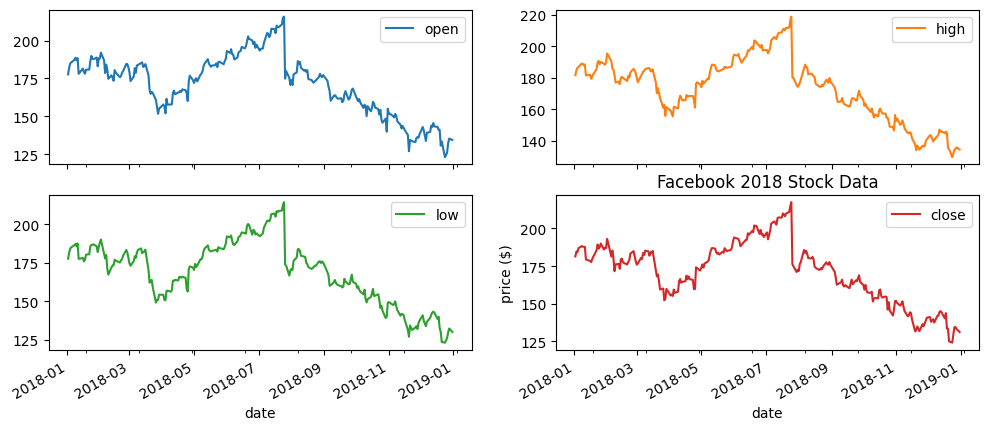

In [41]:
fb.iloc[:,:4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.title('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price ($)')

Simply getting into the habit of using plt.suptitle() instead of plt.title() will save you this confusion

Text(0, 0.5, 'price ($)')

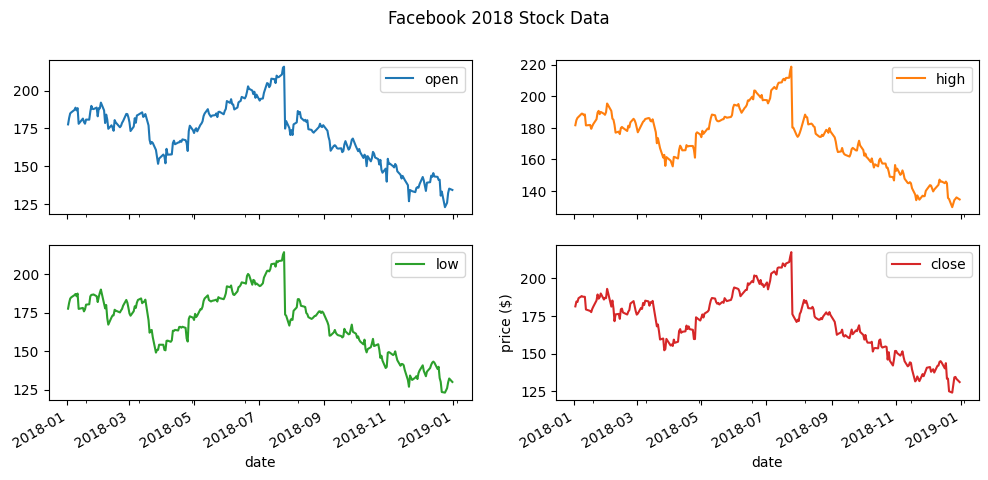

In [42]:
fb.iloc[:,:4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.suptitle('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price ($)')

Legends

plt.legend() adds a legend to the plot. We can specify where to place it with the loc parameter

Text(0, 0.5, 'price ($)')

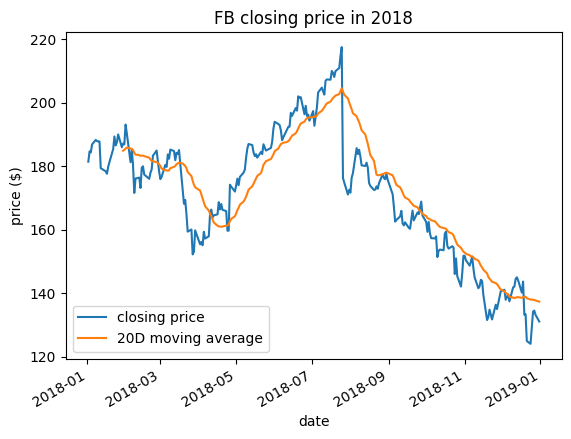

In [43]:
fb.assign(
ma=lambda x: x.close.rolling(20).mean()
).plot(
y=['close', 'ma'],
title='FB closing price in 2018',
label=['closing price', '20D moving average']
)
plt.legend(loc='lower left')
plt.ylabel('price ($)')

he legend, placed in the lower-left corner, clearly labels which line represents the 'closing price' and which represents the '20D moving average.

Formatting axes

plt.xlim() and plt.ylim() can be used to specify the minimum and maximum values for the axis. Passing None will have matplotlib determine the limit.

Text(0, 0.5, 'price ($)')

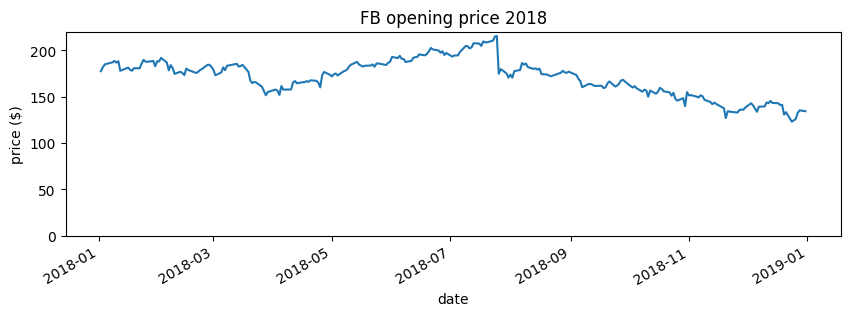

In [44]:
fb.open.plot(figsize=(10, 3), title='FB opening price 2018')
plt.ylim(0, None)
plt.ylabel('price ($)')

plt.ylim(0, None) sets the y-axis limit to start at 0 and automatically determine the upper limit. plt.ylabel('price ($)') simply label.

Formatting the Axis Ticks

ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (6).

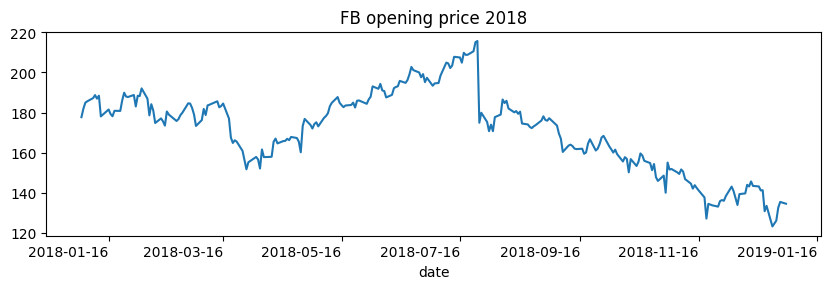

In [45]:
import calendar
fb.open.plot(figsize=(10, 3), rot=0, title='FB opening price 2018')
locs, labels = plt.xticks()
plt.xticks(locs + 15 , calendar.month_name[1::2])
plt.ylabel('price ($)')

PercentFormatter

We can use ticker.PercentFormatter and specify the denominator ( xmax ) to use when calculating the percentages. This gets passed to the
set_major_formatter() method of the xaxis or yaxis on the Axes

Text(0, 0.5, 'percent of highest price ($218.62)')

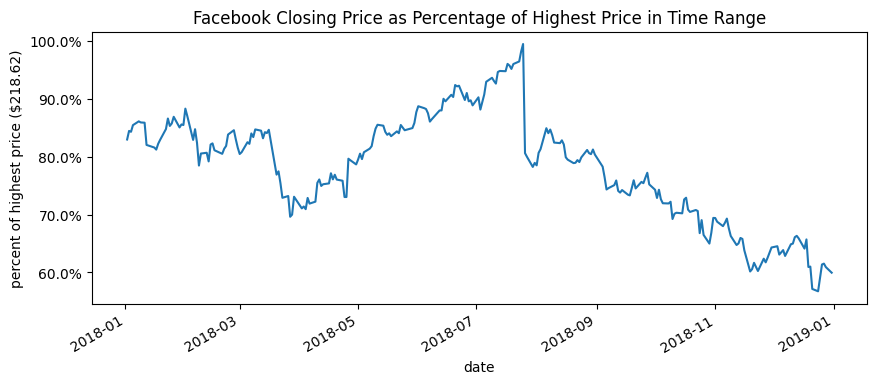

In [46]:
import matplotlib.ticker as ticker
ax = fb.close.plot(
figsize=(10, 4),
title='Facebook Closing Price as Percentage of Highest Price in Time Range'
)
ax.yaxis.set_major_formatter(
ticker.PercentFormatter(xmax=fb.high.max())
)
ax.set_yticks([
fb.high.max()*pct for pct in np.linspace(0.6, 1, num=5)
]) # show round percentages only (60%, 80%, etc.)
ax.set_ylabel(f'percent of highest price (${fb.high.max()})')

This visualization uses the percent formatter to specify the denominator

MultipleLocator

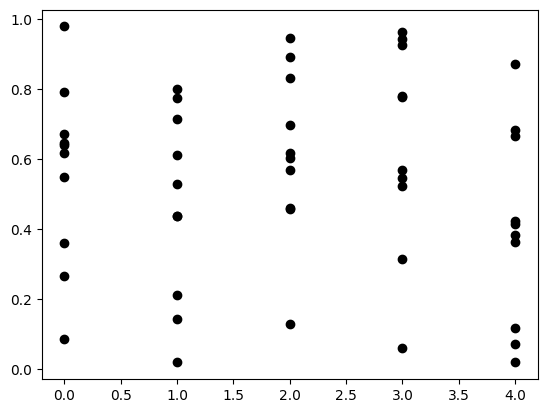

In [47]:
fig, ax = plt.subplots(1, 1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0, 5), 10), np.random.rand(50), 'ko')

If we don't want to show decimal values on the x-axis, we can use the MultipleLocator . This will give ticks for all multiples of a number specified with the base
parameter. To get integer values, we use base=1

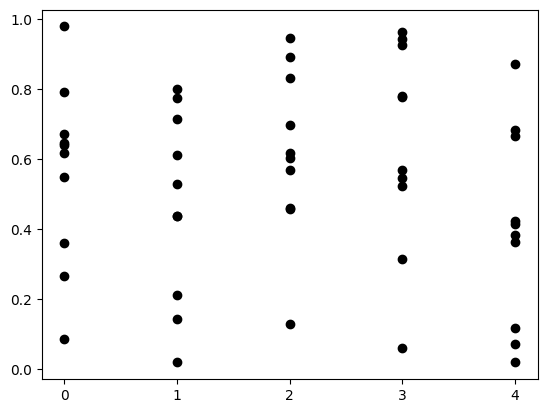

In [48]:
fig, ax = plt.subplots(1, 1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0, 5), 10), np.random.rand(50), 'ko')
ax.get_xaxis().set_major_locator(
ticker.MultipleLocator(base=1))

9.6 Customizing Visualizations

pandas.plotting subpackage

In this notebook, we will be working with Facebook's stock price throughout 2018 (obtained using the stock_analysis package).

Setup

In [50]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
fb = pd.read_csv(
'/content/fb_stock_prices_2018 (1).csv', index_col='date', parse_dates=True)

Scatter matrix

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

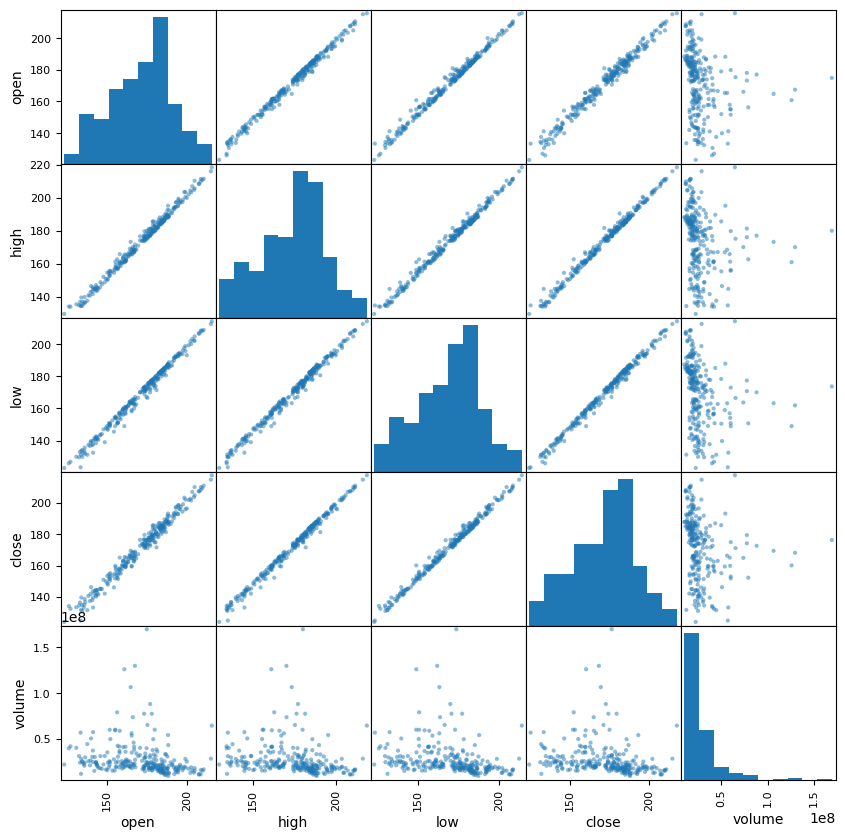

In [51]:
from pandas.plotting import scatter_matrix
scatter_matrix(fb, figsize=(10, 10))


the scatter plot function creates a grid of scatter plots for each pair of variables in a DataFrame. It's a great way to quickly visualize the relationships between multiple variables

Changing the diagonal from histograms to KDE

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

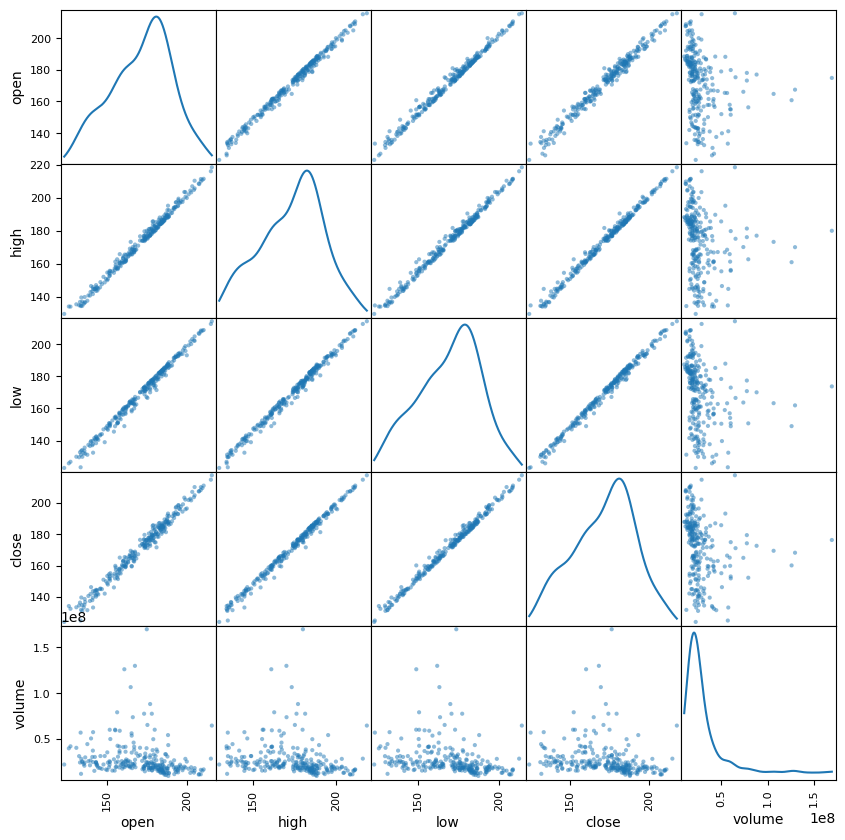

In [52]:
scatter_matrix(fb, figsize=(10, 10), diagonal='kde')


Lag Plot

Lag plots let us see how the variable correlations with past observations of itself. Random data has no pattern

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

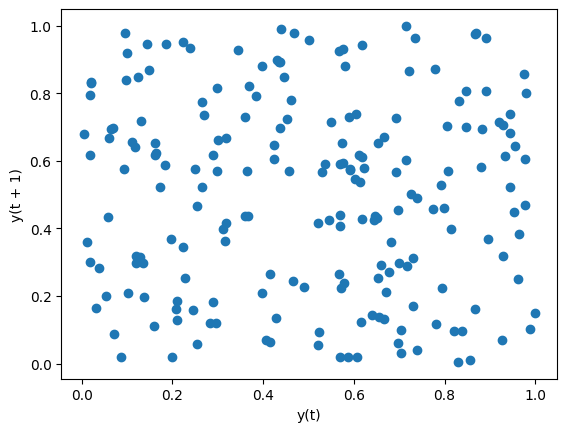

In [53]:
from pandas.plotting import lag_plot
np.random.seed(0) # make this repeatable
lag_plot(pd.Series(np.random.random(size=200)))

lag plot helps us understand the correlation of a variable with its past observations, which is known as autocorrelation.

Data with some level of correlation to itself (autocorrelation) may have patterns. Stock prices are highly auto-correlated

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

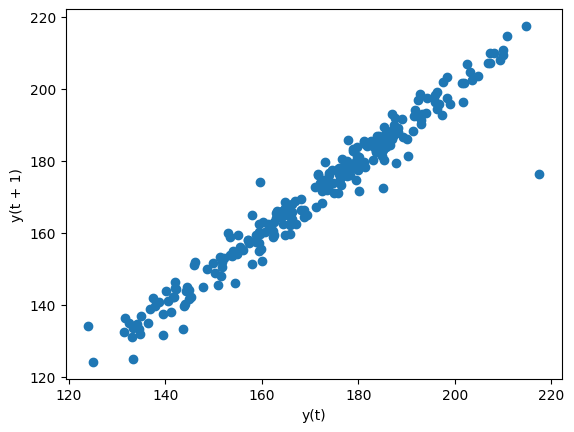

In [54]:
lag_plot(fb.close)

this one shows a data with correlation

The default lag is 1, but we can alter this with the lag parameter. Let's look at a 5 day lag (a week of trading activity):

<Axes: xlabel='y(t)', ylabel='y(t + 5)'>

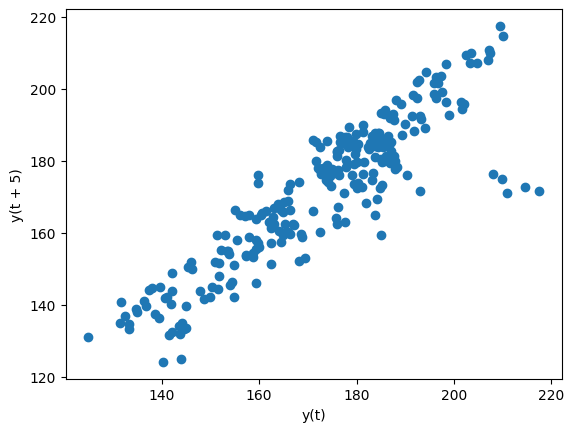

In [55]:
lag_plot(fb.close, lag=5)

Autocorrelation plots

We can use the autocorrelation plot to see if this relationship may be meaningful or just noise. Random data will not have any significant autocorrelation (it stays within the
bounds below):

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

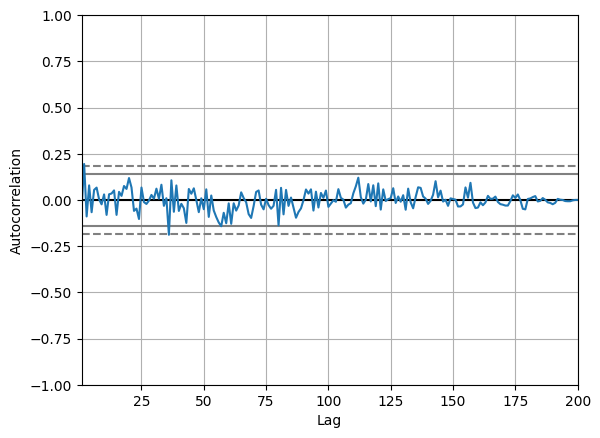

In [56]:
from pandas.plotting import autocorrelation_plot
np.random.seed(0) # make this repeatable
autocorrelation_plot(pd.Series(np.random.random(size=200)))

noise are apparent, significant correlation is not present

Stock data, on the other hand, does have significant autocorrelation

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

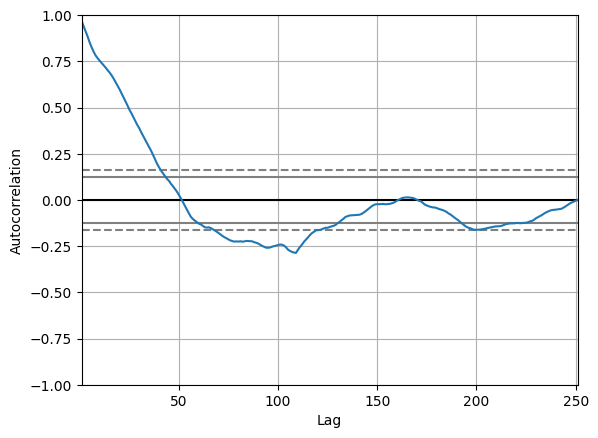

In [57]:
autocorrelation_plot(fb.close)

This one shows significant correlation

Bootstrap plot

This plot helps us understand the uncertainty in our summary statistics:

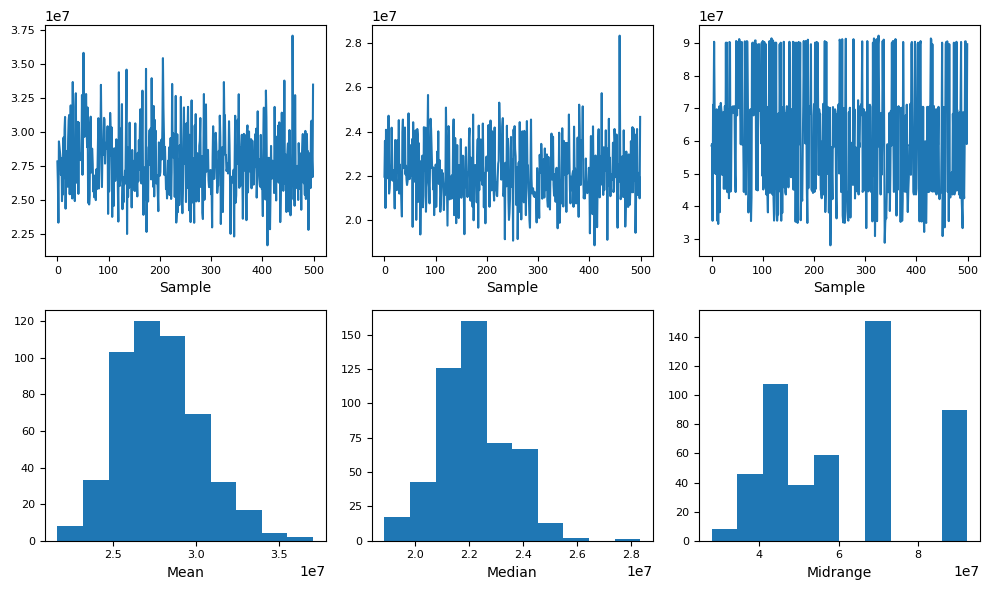

In [58]:
from pandas.plotting import bootstrap_plot
fig = bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10, 6)))


This shows the differences when looking for the mean median and mode. It works by repeatedly resampling the data with replacement, calculating the summary statistic (like the mean or median) for each resample, and then plotting the distribution of these statistics.

Supplementary

1. Using seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami with the magType of mb.

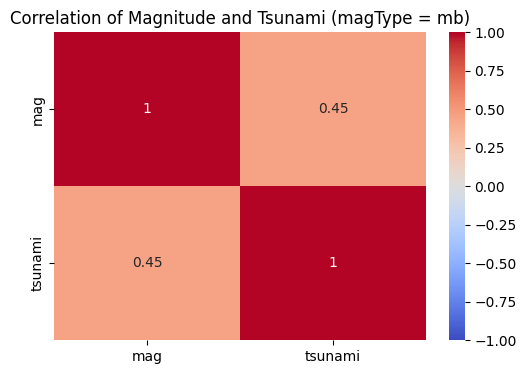

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

quakes = pd.read_csv("/content/earthquakes-1 (1).csv")

mb_quakes = quakes[quakes["magType"] == "mb"]

corr_data = mb_quakes[["mag", "tsunami"]]

corr_matrix = corr_data.corr()

# heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation of Magnitude and Tsunami (magType = mb)")
plt.show()

2. Create a box plot of Facebook volume traded and closing prices, and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 - 1.5 * IQR and Q3 + 1.5 * IQR. Be sure to use the quantile() method on the data to make this easier. (Pick whichever orientation you prefer for the plot, but make sure to use subplots.)

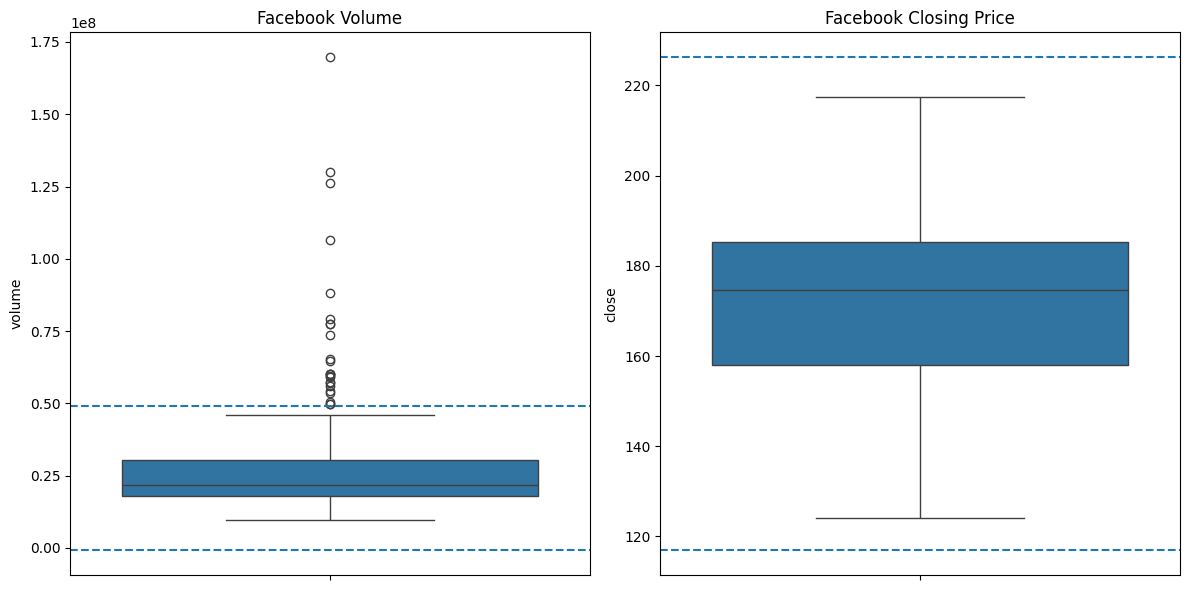

In [61]:
fb = pd.read_csv("/content/fb_stock_prices_2018 (1).csv", parse_dates=["date"], index_col="date")

fig, ax = plt.subplots(1,2, figsize=(12,6))

# Boxplots
sns.boxplot(y=fb["volume"], ax=ax[0])
ax[0].set_title("Facebook Volume")

sns.boxplot(y=fb["close"], ax=ax[1])
ax[1].set_title("Facebook Closing Price")
q1 = fb.quantile(0.25)
q3 = fb.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
ax[0].axhline(lower["volume"], linestyle="--")
ax[0].axhline(upper["volume"], linestyle="--")

ax[1].axhline(lower["close"], linestyle="--")
ax[1].axhline(upper["close"], linestyle="--")

plt.tight_layout()
plt.show()

3. Fill in the area between the bounds in the plot from exercise #2.

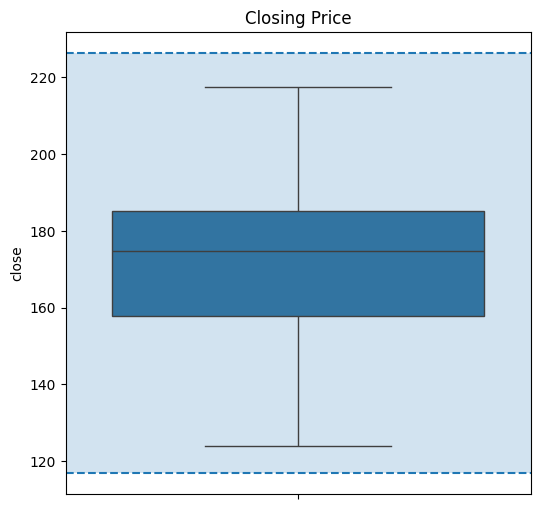

In [62]:
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(y=fb["close"], ax=ax)

ax.axhline(lower["close"], linestyle="--")
ax.axhline(upper["close"], linestyle="--")

ax.axhspan(lower["close"], upper["close"], alpha=0.2)

plt.title("Closing Price")
plt.show()

4. Use axvspan() to shade a rectangle from '2018-07-25' to '2018-07-31', which marks the large decline in Facebook price on a line plot of the closing price.

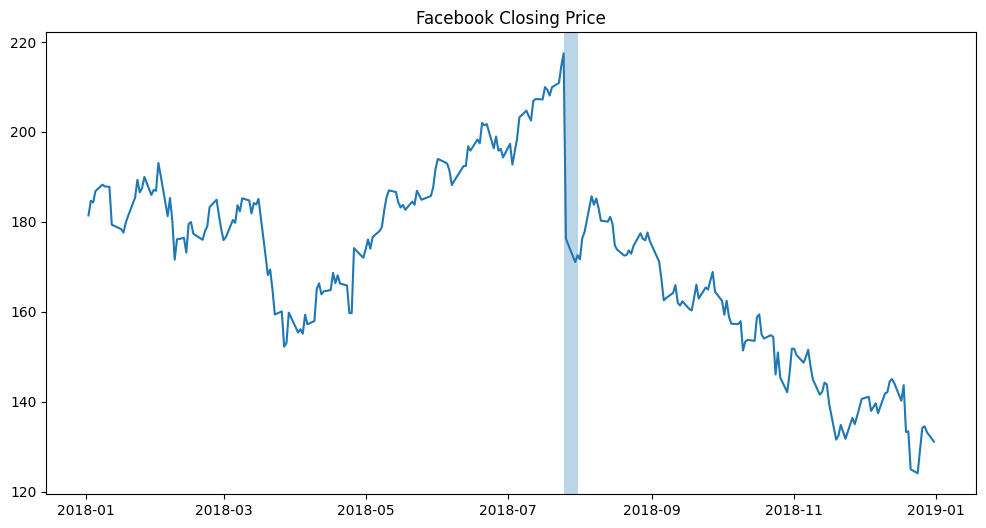

In [63]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(fb.index, fb["close"])

ax.axvspan("2018-07-25", "2018-07-31", alpha=0.3)

ax.set_title("Facebook Closing Price")
plt.show()

5. Using the Facebook stock price data, annotate the following three events on a line plot of the closing price:

- Disappointing user growth announced after close on July 25, 2018
- Cambridge Analytica story breaks on March 19, 2018 (when it affected the market)
- FTC launches investigation on March 20, 2018

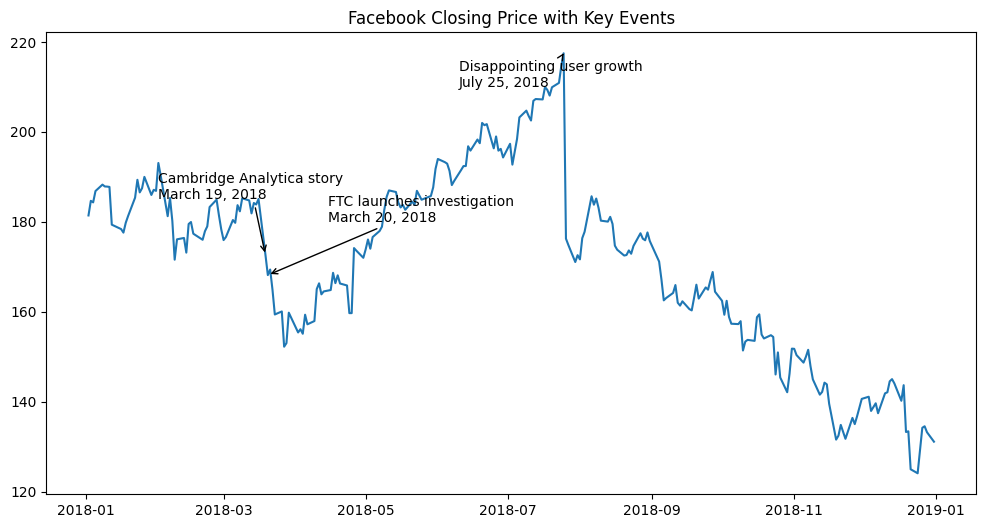

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

fb = pd.read_csv("/content/fb_stock_prices_2018 (1).csv", parse_dates=["date"], index_col="date")

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(fb.index, fb["close"])
d1 = pd.Timestamp("2018-07-25")
d2 = pd.Timestamp("2018-03-19")
d3 = pd.Timestamp("2018-03-20")

ax.annotate(
    "Disappointing user growth\nJuly 25, 2018",
    xy=(d1, fb.loc[d1, "close"]),
    xytext=(pd.Timestamp("2018-06-10"), 210),
    arrowprops=dict(arrowstyle="->"))
ax.annotate(
    "Cambridge Analytica story\nMarch 19, 2018",
    xy=(d2, fb.loc[d2, "close"]),
    xytext=(pd.Timestamp("2018-02-01"), 185),
    arrowprops=dict(arrowstyle="->"))

ax.annotate(
    "FTC launches investigation\nMarch 20, 2018",
    xy=(d3, fb.loc[d3, "close"]),
    xytext=(pd.Timestamp("2018-04-15"), 180),
    arrowprops=dict(arrowstyle="->"))
ax.set_title("Facebook Closing Price with Key Events")
plt.show()

6. Modify the reg_resid_plots() function to use a matplotlib colormap instead of cycling between two colors. Remember, for this use case, we should pick a qualitative colormap or make our own.

In [75]:
import matplotlib.pyplot as plt
import numpy as np

def reg_resid_plots(x, y, models):

    cmap = plt.get_cmap("tab10")
    colors = cmap(np.linspace(0,1,len(models)))

    fig, axes = plt.subplots(len(models), 2, figsize=(10,5*len(models)))

    for i, model in enumerate(models):

        axes[i,0].scatter(x, y, color=colors[i])
        axes[i,0].plot(x, model.predict(x.reshape(-1,1)), color=colors[i])
        axes[i,0].set_title(f"Regression Plot {i+1}")

        residuals = y - model.predict(x.reshape(-1,1))
        axes[i,1].scatter(model.predict(x.reshape(-1,1)), residuals, color=colors[i])
        axes[i,1].axhline(0, linestyle="--")
        axes[i,1].set_title(f"Residual Plot {i+1}")

    plt.tight_layout()
    plt.show()

Conclusion

This activity showed how data visualization can help analyze and understand datasets. Heatmaps were used to examine the relationship between earthquake magnitude and tsunamis, while box plots and Tukey fences helped identify outliers in Facebook stock data. Line plots with shaded areas and annotations highlighted important events that affected Facebook’s stock price. Overall, the activity demonstrated how visualizations can reveal patterns, relationships, and important changes in data.
